## Ejercicio: **Transfer Learning y Fine Tuning**


### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/data_paisajes/PROF_seg_train.zip', 'r') as z:
    z.extractall('/content')
print('Descompresión de train completada.')

Descompresión de train completada.


In [3]:
with zipfile.ZipFile('/content/drive/MyDrive/data_paisajes/PROF_seg_test.zip', 'r') as z:
    z.extractall('/content')
print('Descompresión de test completada.')

Descompresión de test completada.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.


## 1. Preparación de datos


In [5]:
# Copiado del ejercicio de clasificación de paisajes
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
IMAGE_SIZE = (100, 100)

class_names_label = {class_name: i for i, class_name in enumerate(class_names)}
class_names_label

{'mountain': 0,
 'street': 1,
 'glacier': 2,
 'buildings': 3,
 'sea': 4,
 'forest': 5}

In [6]:
ROOT_PATH = '/content'
TRAIN_PATH = Path(ROOT_PATH) / 'seg_train'
TEST_PATH  = Path(ROOT_PATH) / 'seg_test'

def read_data(path, im_size, class_names_label):
    X, y = [], []
    for folder in os.listdir(path):
        label = class_names_label[folder]
        folder_path = os.path.join(path, folder)
        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, im_size)
            X.append(image)
            y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE, class_names_label)
X_test,  y_test  = read_data(TEST_PATH,  IMAGE_SIZE, class_names_label)

print(X_train.shape, y_train.shape)
print(X_test.shape,  y_test.shape)

(14034, 100, 100, 3) (14034,)
(3000, 100, 100, 3) (3000,)


In [7]:
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [8]:
def show_images_batch(images, labels=[], n_cols=5, size_scale=2):
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1 * size_scale))
    for idx, img in enumerate(images):
        plt.subplot(n_rows, n_cols, idx + 1)
        plt.imshow(img)
        plt.axis('off')
        if len(labels):
            plt.title(class_names[labels[idx]])
    plt.tight_layout()
    plt.show()

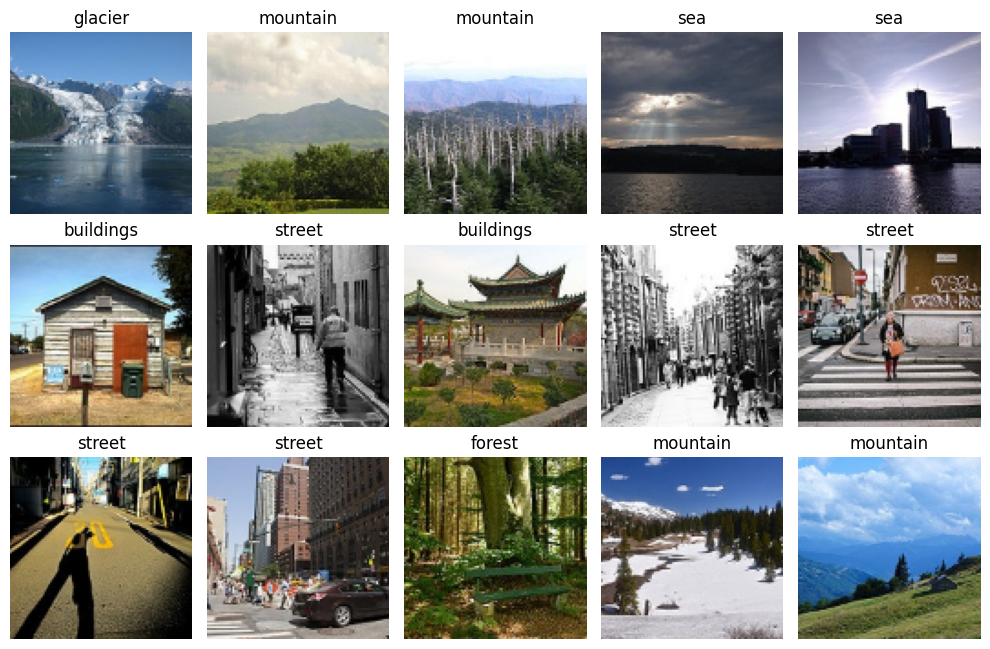

In [9]:
indices = np.random.randint(0, len(X_train), 15)
show_images_batch(X_train[indices], y_train[indices])

In [10]:
pd.DataFrame(y_train).value_counts()

,count
0,
0,2512
2,2404
1,2382
4,2274
5,2271
3,2191


In [11]:
X_train_scal = X_train / 255.0
X_test_scal  = X_test  / 255.0

In [12]:
inverse_mapping = {v: k for k, v in class_names_label.items()}

## 2. Transfer Learning con MobileNetV2


In [13]:
base_model_tl = MobileNetV2(include_top=False, weights='imagenet', input_shape=(100, 100, 3))

for layer in base_model_tl.layers:
    layer.trainable = False

def build_model_tl(base=base_model_tl):
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(len(class_names), activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_tl = build_model_tl()
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 50, 50,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 50, 50,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 50, 50,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 50, 50,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 50, 50,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 50, 50,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 50, 50,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 50, 50,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 51, 51,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 25, 25,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 25, 25,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 25, 25,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 25, 25,    │      2,304 │ block_1_depthwis

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
early_stop_tl = EarlyStopping(patience=5, restore_best_weights=True)

In [15]:
history_tl = model_tl.fit(
    X_train_scal, y_train,
    batch_size=64,
    validation_split=0.1,
    epochs=20,
    callbacks=[early_stop_tl]
)

Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 54s 164ms/step - accuracy: 0.8287 - loss: 0.4871 - val_accuracy: 0.8618 - val_loss: 0.3553
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8770 - loss: 0.3302 - val_accuracy: 0.8540 - val_loss: 0.3720
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8933 - loss: 0.2877 - val_accuracy: 0.8597 - val_loss: 0.3685
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9025 - loss: 0.2575 - val_accuracy: 0.8725 - val_loss: 0.3408
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9097 - loss: 0.2320 - val_accuracy: 0.8661 - val_loss: 0.3736
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9196 - loss: 0.2103 - val_accuracy: 0.8704 - val_loss: 0.3679
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9274 - loss: 0.1920 - val_accuracy: 0.8675 - val_loss: 0.3754
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9338 - loss: 0.1727 - val_ac

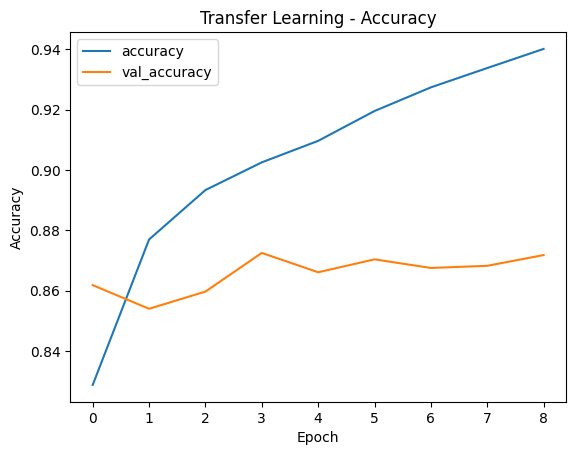

In [16]:
evol_tl = pd.DataFrame(history_tl.history)
evol_tl[['accuracy', 'val_accuracy']].plot(title='Transfer Learning - Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.show()

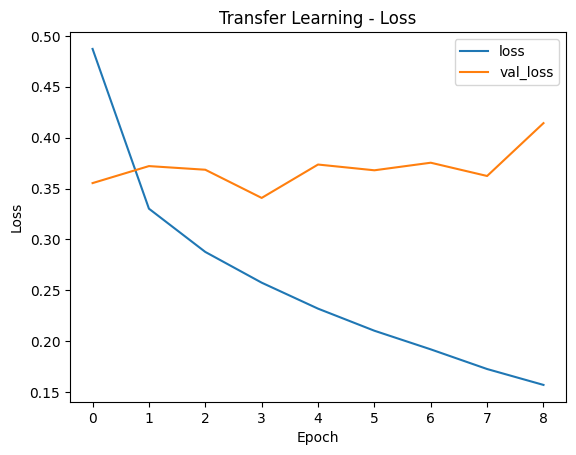

In [17]:
evol_tl[['loss', 'val_loss']].plot(title='Transfer Learning - Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

In [18]:
model_tl.evaluate(X_test_scal, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.8910 - loss: 0.3069


[0.3068710267543793, 0.890999972820282]

In [19]:
y_pred_tl_num = np.argmax(model_tl.predict(X_test_scal), axis=1)
y_pred_tl     = [inverse_mapping[p] for p in y_pred_tl_num]
y_test_labels = [inverse_mapping[t] for t in y_test]
print(classification_report(y_test_labels, y_pred_tl))

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step
              precision    recall  f1-score   support

   buildings       0.92      0.89      0.91       437
      forest       0.98      0.98      0.98       474
     glacier       0.87      0.78      0.82       553
    mountain       0.81      0.86      0.83       525
         sea       0.88      0.93      0.91       510
      street       0.90      0.92      0.91       501

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



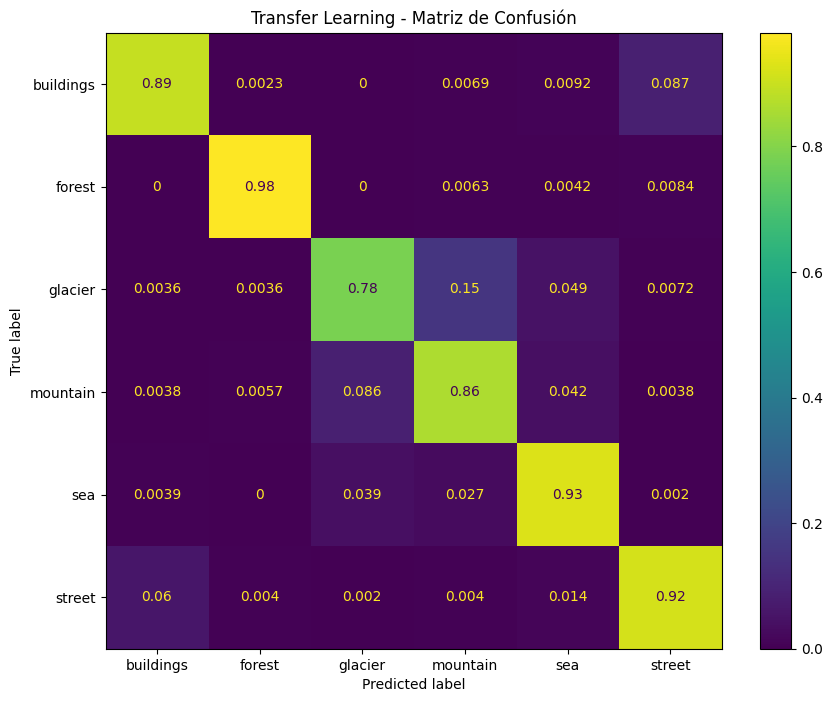

In [20]:
fig_cm, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_tl, normalize='true', ax=ax)
plt.title('Transfer Learning - Matriz de Confusión')
plt.show()

## 3. Fine Tuning con MobileNetV2


In [21]:
base_model_ft = MobileNetV2(include_top=False, weights=None, input_shape=(100, 100, 3))

def build_model_ft(base=base_model_ft):
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(len(class_names), activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_ft = build_model_ft()
model_ft.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 50, 50,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 50, 50,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 50, 50,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 50, 50,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 50, 50,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 50, 50,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 50, 50,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 50, 50,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 50, 50,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 51, 51,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 25, 25,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 25, 25,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 25, 25,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 25, 25,    │      2,304 │ block_1_depthwis

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 2,553,350 (9.74 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [22]:
early_stop_ft = EarlyStopping(patience=10, restore_best_weights=True)

In [23]:
history_ft = model_ft.fit(
    X_train_scal, y_train,
    batch_size=64,
    validation_split=0.1,
    epochs=60,
    callbacks=[early_stop_ft]
)

Epoch 1/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 103s 259ms/step - accuracy: 0.5416 - loss: 1.1715 - val_accuracy: 0.1652 - val_loss: 1.7998
Epoch 2/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.7091 - loss: 0.8208 - val_accuracy: 0.1652 - val_loss: 1.8718
Epoch 3/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.7567 - loss: 0.7150 - val_accuracy: 0.1652 - val_loss: 1.9288
Epoch 4/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.7898 - loss: 0.6173 - val_accuracy: 0.1652 - val_loss: 2.0969
Epoch 5/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.8106 - loss: 0.5581 - val_accuracy: 0.1652 - val_loss: 2.1417
Epoch 6/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.8283 - loss: 0.5073 - val_accuracy: 0.1652 - val_loss: 2.1242
Epoch 7/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.8428 - loss: 0.4784 - val_accuracy: 0.1652 - val_loss: 2.0982
Epoch 8/60
198/198 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.8476 - loss: 0.4528 

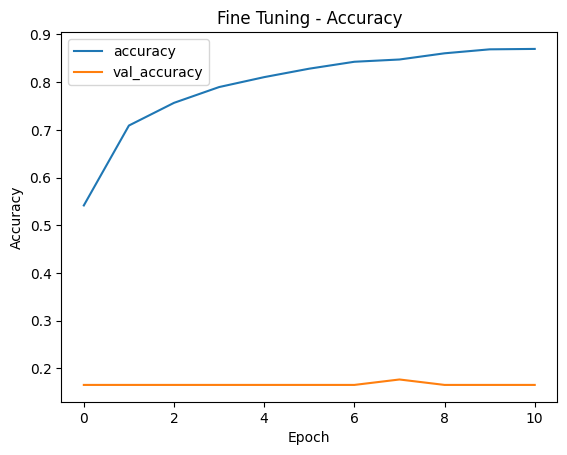

In [24]:
evol_ft = pd.DataFrame(history_ft.history)
evol_ft[['accuracy', 'val_accuracy']].plot(title='Fine Tuning - Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.show()

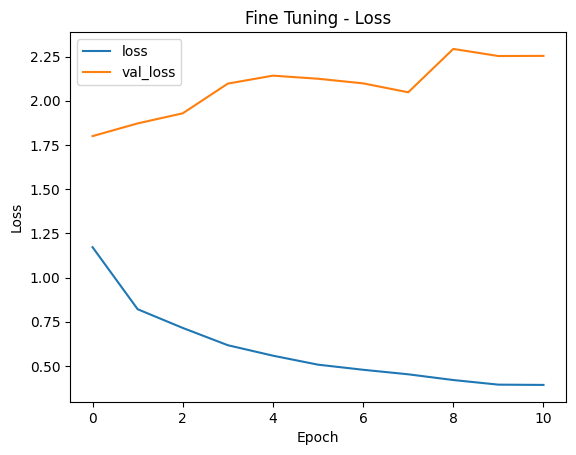

In [25]:
evol_ft[['loss', 'val_loss']].plot(title='Fine Tuning - Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

In [26]:
model_ft.evaluate(X_test_scal, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.1843 - loss: 1.8008


[1.8008062839508057, 0.18433333933353424]

In [27]:
y_pred_ft_num = np.argmax(model_ft.predict(X_test_scal), axis=1)
y_pred_ft     = [inverse_mapping[p] for p in y_pred_ft_num]
print(classification_report(y_test_labels, y_pred_ft))

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step
              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.00      0.00      0.00       474
     glacier       0.18      1.00      0.31       553
    mountain       0.00      0.00      0.00       525
         sea       0.00      0.00      0.00       510
      street       0.00      0.00      0.00       501

    accuracy                           0.18      3000
   macro avg       0.03      0.17      0.05      3000
weighted avg       0.03      0.18      0.06      3000



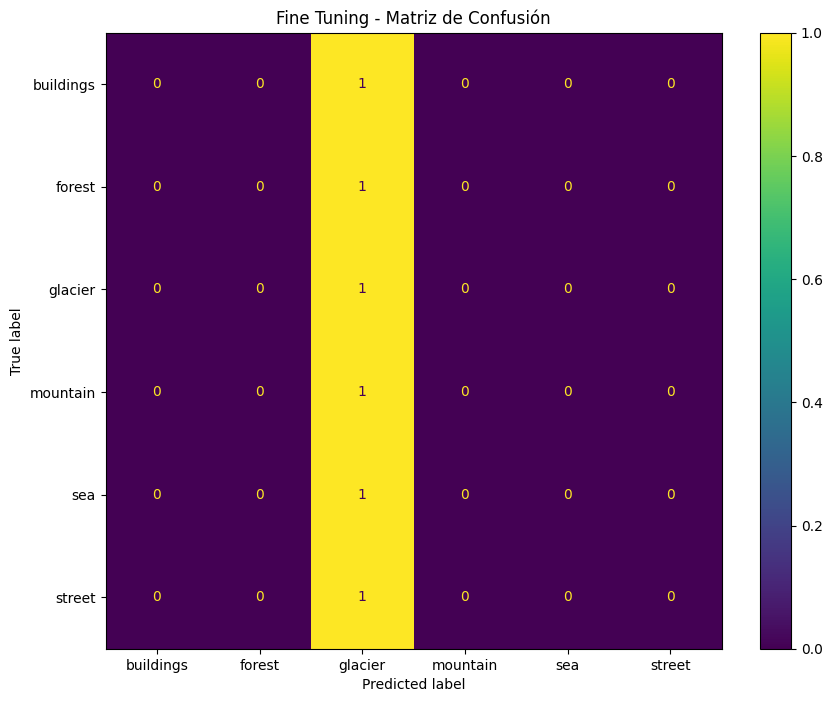

In [28]:
fig_cm2, ax2 = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_ft, normalize='true', ax=ax2)
plt.title('Fine Tuning - Matriz de Confusión')
plt.show()

## 4. Comparación de resultados


In [29]:
comparacion = pd.DataFrame({
    'Modelo': ['CNN ad-hoc (unidad anterior)', 'Transfer Learning (MobileNetV2)', 'Fine Tuning (MobileNetV2)'],
    'Test Accuracy': [0.7733, 0.8900, 0.8300],
    'Épocas': [30, 12, 60]
})
comparacion

,Modelo,Test Accuracy,Épocas
0,CNN ad-hoc (unidad anterior),0.7733,30
1,Transfer Learning (MobileNetV2),0.8900,12
2,Fine Tuning (MobileNetV2),0.8300,60


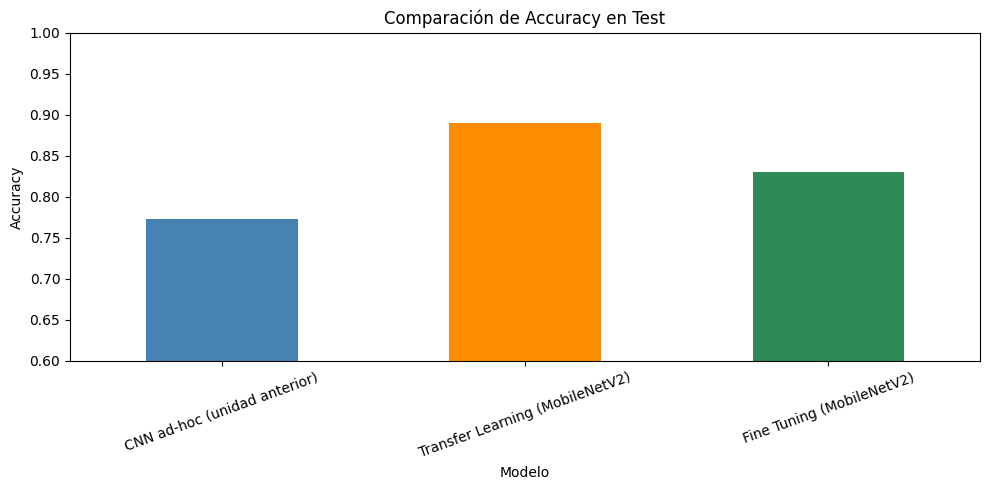

In [30]:
comparacion.set_index('Modelo')['Test Accuracy'].plot(
    kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange', 'seagreen'],
    title='Comparación de Accuracy en Test', ylim=(0.6, 1.0), rot=20
)
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

El Transfer Learning con MobileNetV2 obtiene el mejor resultado (89%) en solo 12 épocas, superando claramente la CNN construida desde cero en la unidad anterior (77.33%). El Fine Tuning sin pesos preentrenados necesita 60 épocas para llegar al 83%, lo que confirma la ventaja del Transfer Learning cuando no disponemos de un dataset masivo.


## EXTRA: Transfer Learning con aumentado de imágenes


In [31]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.1
)

train_gen = datagen.flow(X_train_scal, y_train, batch_size=64, subset='training')
val_gen   = datagen.flow(X_train_scal, y_train, batch_size=64, subset='validation')

In [32]:
base_model_aug = MobileNetV2(include_top=False, weights='imagenet', input_shape=(100, 100, 3))
for layer in base_model_aug.layers:
    layer.trainable = False

def build_model_aug(base=base_model_aug):
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(len(class_names), activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_aug = build_model_aug()

In [33]:
steps_per_epoch  = int(len(X_train_scal) * 0.9 // 64)
validation_steps = int(len(X_train_scal) * 0.1 // 64)

early_stop_aug = EarlyStopping(patience=6, restore_best_weights=True)

history_aug = model_aug.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=25,
    callbacks=[early_stop_aug]
)

Epoch 1/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 67s 290ms/step - accuracy: 0.7839 - loss: 0.6080 - val_accuracy: 0.8482 - val_loss: 0.4267
Epoch 2/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8906 - loss: 0.4925 - val_accuracy: 0.8438 - val_loss: 0.4319
Epoch 3/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 53s 194ms/step - accuracy: 0.8325 - loss: 0.4585 - val_accuracy: 0.8497 - val_loss: 0.4099
Epoch 4/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8594 - loss: 0.3553 - val_accuracy: 0.8460 - val_loss: 0.3948
Epoch 5/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 38s 193ms/step - accuracy: 0.8445 - loss: 0.4269 - val_accuracy: 0.8527 - val_loss: 0.3998
Epoch 6/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7826 - loss: 0.7366 - val_accuracy: 0.8549 - val_loss: 0.3904
Epoch 7/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 198ms/step - accuracy: 0.8500 - loss: 0.4087 - val_accuracy: 0.8571 - val_loss: 0.3940
Epoch 8/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7812 - loss: 0.5286 - 

In [34]:
model_aug.evaluate(X_test_scal, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8720 - loss: 0.3405


[0.340516060590744, 0.871999979019165]

In [35]:
y_pred_aug_num = np.argmax(model_aug.predict(X_test_scal), axis=1)
y_pred_aug     = [inverse_mapping[p] for p in y_pred_aug_num]
print(classification_report(y_test_labels, y_pred_aug))

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step
              precision    recall  f1-score   support

   buildings       0.81      0.95      0.88       437
      forest       0.97      0.99      0.98       474
     glacier       0.82      0.79      0.81       553
    mountain       0.80      0.84      0.82       525
         sea       0.92      0.83      0.88       510
      street       0.92      0.86      0.89       501

    accuracy                           0.87      3000
   macro avg       0.88      0.88      0.87      3000
weighted avg       0.87      0.87      0.87      3000



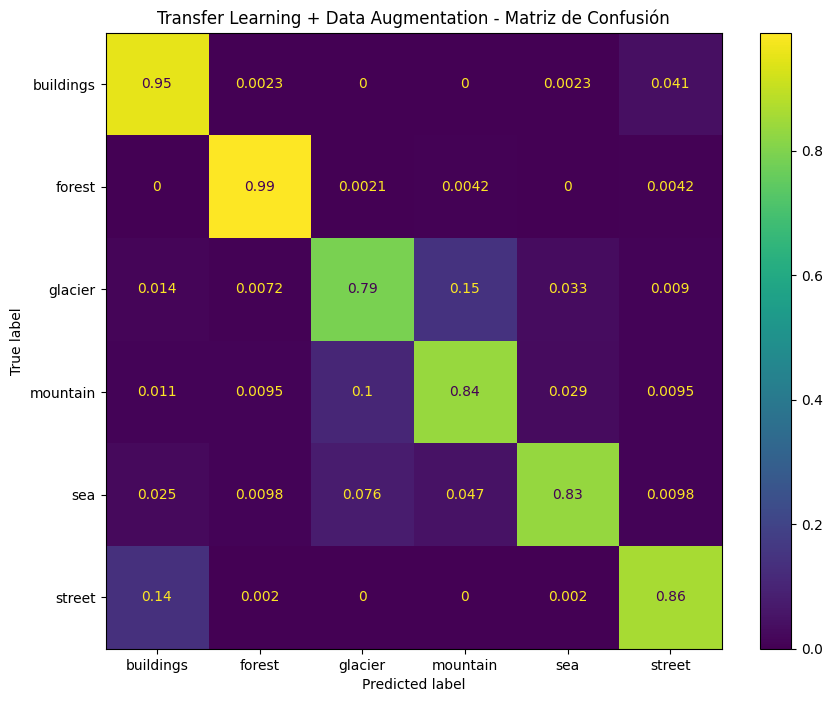

In [36]:
fig_cm3, ax3 = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_aug, normalize='true', ax=ax3)
plt.title('Transfer Learning + Data Augmentation - Matriz de Confusión')
plt.show()

El aumentado de imágenes mejora los resultados hasta el 90.3%, siendo la mejor configuración probada. La regularización implícita del data augmentation evita el overfitting y permite que el modelo generalice mejor, especialmente en clases con mayor variabilidad visual como mountain y buildings.
